In [10]:
import geopandas as gpd 
import os

Define features columns and target column

In [11]:
features = ['r_mean','r_median', 'r_std','r_var', 'g_mean','g_median', 'g_std','g_var', 'b_mean','b_median','b_var', 'b_std','area']
target = 'OBSERV_GROUP'

### Option 1 : Get the pre-splits

These splits were generated from a stratified split, see [this notebook](./train_test_split.ipynb)

In [ ]:
train_gdf = gpd.read_file(os.path.join(os.getcwd(),'..','data','geojson','train_files.geojson'))

test_gdf = gpd.read_file(os.path.join(os.getcwd(),'..','data','geojson','test_files.geojson'))

In [3]:
train_gdf

,CODIGO,OBSERV,INSUMO,APOYO,ASIGNACION,Asignado,OAM,area,url_type,download_url,...,g_mean,g_median,g_std,g_var,b_mean,b_median,b_std,b_var,CODIGO_GROUP,geometry
0,0,building,Map1_Orthomosaic_ThuJul24202452191338,None,Sofia,None,https://drive.google.com/drive/folders/1PoaKqU...,54.139512,gdrive,https://drive.google.com/file/d/1T1Pin5cXsCcu4...,...,205.605074,227.0,54.732962,2995.697165,190.791912,214.0,61.152457,3739.622993,0,"POLYGON ((-73.24313 11.25111, -73.24314 11.251..."
1,0,building,961,None,Sofia,None,https://map.openaerialmap.org/#/-77.4261206388...,104.680054,oam,https://oin-hotosm-temp.s3.us-east-1.amazonaws...,...,128.036882,129.0,65.329558,4267.951132,117.081532,107.0,81.185142,6591.027328,0,"POLYGON ((-77.42661 1.04871, -77.42669 1.04872..."
2,112,urban not continuous,MapPlan_Orthomosaic_ThuJul24202849972911,None,Sofia,None,https://drive.google.com/drive/folders/1QRkuTF...,283.000199,gdrive,https://drive.google.com/file/d/1uDznoDuGo5OsS...,...,176.645139,207.0,77.495977,6005.626445,178.040137,217.0,82.348225,6781.230110,11,"POLYGON ((-72.26548 11.36997, -72.26549 11.369..."
3,22,permanent crops,Santa Rosa,None,None,Juan,https://map.openaerialmap.org/#/-76.5763378143...,14940.149489,oam,https://oin-hotosm-temp.s3.us-east-1.amazonaws...,...,109.128906,109.0,39.064442,1526.030626,58.886060,54.0,35.320168,1247.514251,22,"POLYGON ((-76.57316 1.70816, -76.57307 1.70812..."
4,22,permanent crops,1175,None,Sofia,None,https://map.openaerialmap.org/#/-75.6697082519...,3840.901611,oam,https://oin-hotosm-temp.s3.us-east-1.amazonaws...,...,123.623597,130.0,36.791095,1353.584665,77.938724,78.0,32.494331,1055.881557,22,"POLYGON ((-75.67163 6.19024, -75.67151 6.19028..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1537,0,building,MapPlan_Orthomosaic_ThuJul24202849972911,None,Sofia,None,https://drive.google.com/drive/folders/1QRkuTF...,24.848614,gdrive,https://drive.google.com/file/d/1uDznoDuGo5OsS...,...,219.875190,247.0,53.746206,2888.654662,214.689229,249.0,64.765523,4194.572925,0,"POLYGON ((-72.26377 11.37022, -72.2638 11.3702..."
1538,0,building,1175,None,Sofia,None,https://map.openaerialmap.org/#/-75.6697082519...,278.316951,oam,https://oin-hotosm-temp.s3.us-east-1.amazonaws...,...,132.139372,133.0,31.927362,1019.356443,89.507846,87.0,28.383239,805.608281,0,"POLYGON ((-75.67342 6.19721, -75.67361 6.19716..."
1539,0,building,1175,None,Sofia,None,https://map.openaerialmap.org/#/-75.6697082519...,151.513593,oam,https://oin-hotosm-temp.s3.us-east-1.amazonaws...,...,158.537087,157.0,41.192116,1696.790387,108.309472,92.0,55.570829,3088.117043,0,"POLYGON ((-75.66485 6.19083, -75.66483 6.19078..."
1540,232,wooded pasture,Santa Rosa,None,None,Juan,https://map.openaerialmap.org/#/-76.5763378143...,34037.140830,oam,https://oin-hotosm-temp.s3.us-east-1.amazonaws...,...,117.447445,119.0,30.361819,921.840039,56.179153,55.0,23.242664,540.221410,23,"POLYGON ((-76.57287 1.72744, -76.57279 1.72733..."


Initialize the CODIGO_GROUP column for land cover labels

In [22]:
train_gdf['OBSERV_GROUP'] = train_gdf['CODIGO_GROUP'].replace({
    '0' : 'Building',
    '11' : 'Urban',
    '12' : 'Highway',
    '21' : 'Seasonal crops',
    '22' : 'Permanent crops',
    '23' : 'Pasture',
    '31' : 'Forest',
    '32' : 'Grassland',
    '33' : 'Bare areas',
    '51' : 'Water'
})

test_gdf['OBSERV_GROUP'] = test_gdf['CODIGO_GROUP'].replace({
    '0' : 'Building',
    '11' : 'Urban',
    '12' : 'Highway',
    '21' : 'Seasonal crops',
    '22' : 'Permanent crops',
    '23' : 'Pasture',
    '31' : 'Forest',
    '32' : 'Grassland',
    '33' : 'Bare areas',
    '51' : 'Water'
})

X_train = train_gdf[features]
y_train = train_gdf[target]
X_test = test_gdf[features]
y_test = test_gdf[target]

### Option 2 : Get full dataset
We initialize the full dataset to perform cross-validaton and other methods which don't need manual splits

In [12]:
gdf = gpd.read_file(os.path.join(os.getcwd(),'..','data','geojson','polygon_cleaned_with_stats.geojson'))

# Add OBSERV_GROUP to get land labels
gdf['CODIGO_GROUP'] = gdf['CODIGO'].astype(str).str[:2]


gdf['OBSERV_GROUP'] = gdf['CODIGO_GROUP'].replace({
    '0' : 'Building',
    '11' : 'Urban',
    '12' : 'Highway',
    '21' : 'Seasonal crops',
    '22' : 'Permanent crops',
    '23' : 'Pasture',
    '31' : 'Forest',
    '32' : 'Grassland',
    '33' : 'Bare areas',
    '51' : 'Water'
})

X_train_full = gdf[features]
y_train_full = gdf[target]

In [33]:
# Count number of samples per class
class_counts = y_test.value_counts()
print("Class distribution in the full dataset:")
print(class_counts)

Class distribution in the full dataset:
OBSERV_GROUP
Building           133
Pasture            101
Forest              47
Bare areas          31
Urban               31
Permanent crops     12
Water                8
Grassland            8
Seasonal crops       8
Highway              7
Name: count, dtype: int64


In [14]:
list(gdf['OBSERV_GROUP'].unique())

['Pasture',
 'Seasonal crops',
 'Urban',
 'Forest',
 'Permanent crops',
 'Building',
 'Bare areas',
 'Grassland',
 'Highway',
 'Water']

In [16]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

def compute_accuracy(classifier, X, y, train_gdf):
    y_pred = classifier.predict(X)
    overall_accuracy = accuracy_score(y, y_pred)
    classification_accuracy= classification_report(y, y_pred,zero_division=1)
    
    labels = list(train_gdf['OBSERV_GROUP'].unique())

    cm = confusion_matrix(y, y_pred, labels=labels)

    cmd = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels, )
    
    cm_norm = confusion_matrix(y, y_pred, labels=labels, normalize='true')
    
    cmd_norm = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=labels)

    # Add gaps between the two plots
    fig, ax = plt.subplots(1, 2, figsize=(12, 6), gridspec_kw={'wspace': 0.4})
    cmd.plot(ax=ax[0], cmap=plt.cm.Blues, colorbar=False, xticks_rotation=90)
    cmd_norm.plot(ax=ax[1], cmap=plt.cm.Blues, colorbar=False, xticks_rotation=90)
    ax[0].set_title('Confusion Matrix')
    ax[1].set_title('Normalized Confusion Matrix')
    plt.show()
    return overall_accuracy, classification_accuracy 


Fold 1 Results:


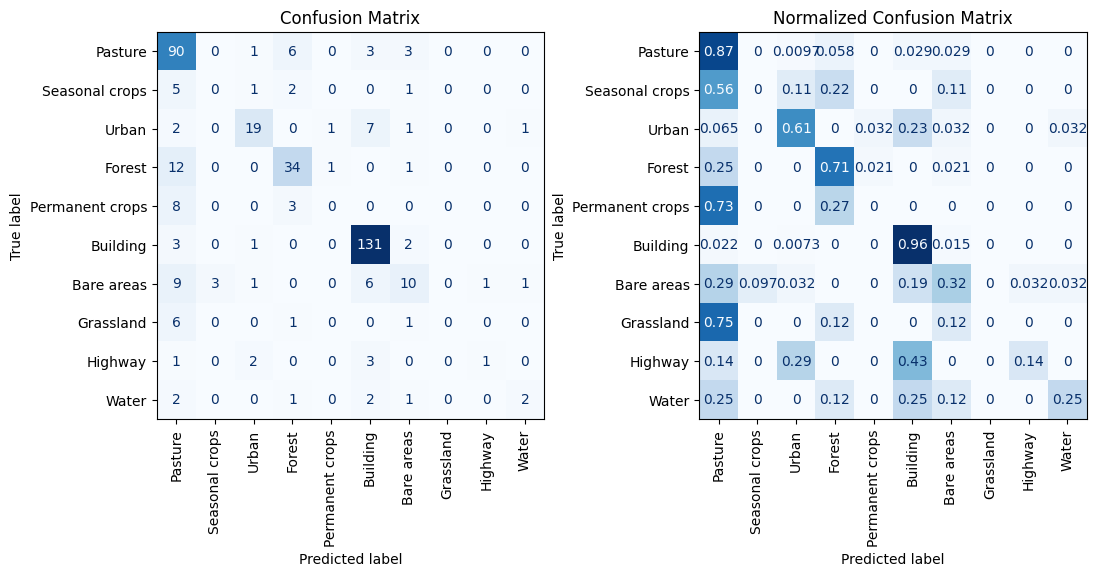

Overall Accuracy: 0.7302798982188295
Classification Report:
                 precision    recall  f1-score   support

     Bare areas       0.50      0.32      0.39        31
       Building       0.86      0.96      0.91       137
         Forest       0.72      0.71      0.72        48
      Grassland       1.00      0.00      0.00         8
        Highway       0.50      0.14      0.22         7
        Pasture       0.65      0.87      0.75       103
Permanent crops       0.00      0.00      0.00        11
 Seasonal crops       0.00      0.00      0.00         9
          Urban       0.76      0.61      0.68        31
          Water       0.50      0.25      0.33         8

       accuracy                           0.73       393
      macro avg       0.55      0.39      0.40       393
   weighted avg       0.70      0.73      0.69       393

--------------------------------------------------
Fold 2 Results:


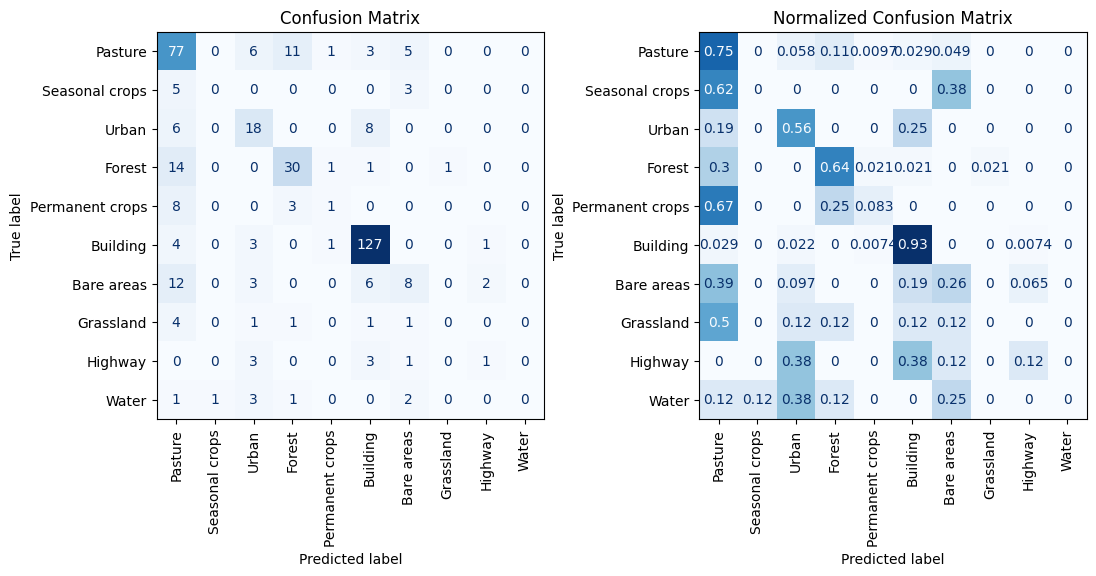

Overall Accuracy: 0.6666666666666666
Classification Report:
                 precision    recall  f1-score   support

     Bare areas       0.40      0.26      0.31        31
       Building       0.85      0.93      0.89       136
         Forest       0.65      0.64      0.65        47
      Grassland       0.00      0.00      0.00         8
        Highway       0.25      0.12      0.17         8
        Pasture       0.59      0.75      0.66       103
Permanent crops       0.25      0.08      0.12        12
 Seasonal crops       0.00      0.00      0.00         8
          Urban       0.49      0.56      0.52        32
          Water       1.00      0.00      0.00         8

       accuracy                           0.67       393
      macro avg       0.45      0.33      0.33       393
   weighted avg       0.63      0.67      0.63       393

--------------------------------------------------
Fold 3 Results:


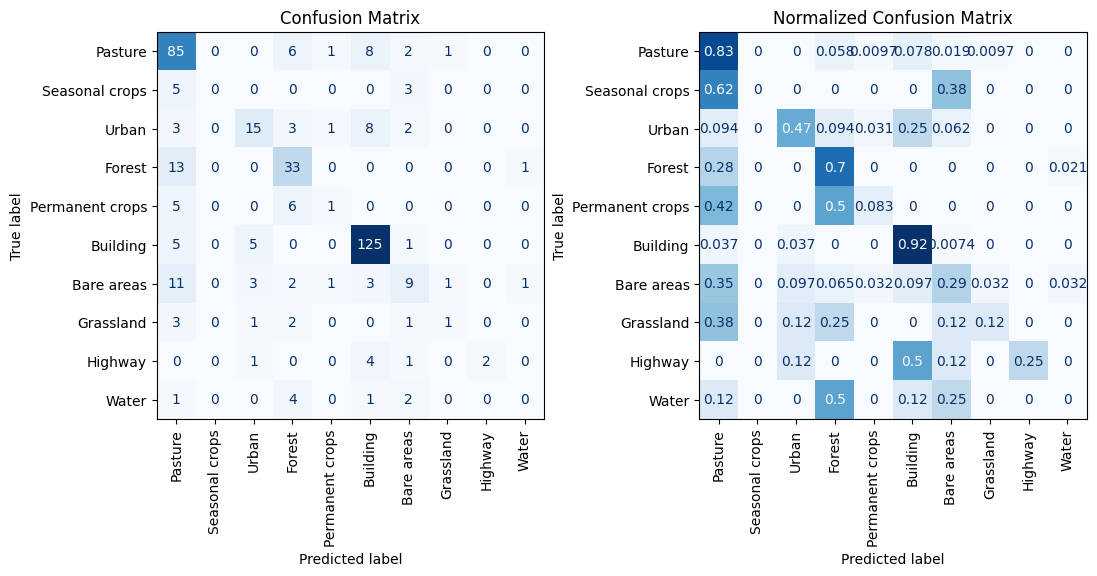

Overall Accuracy: 0.6895674300254453
Classification Report:
                 precision    recall  f1-score   support

     Bare areas       0.43      0.29      0.35        31
       Building       0.84      0.92      0.88       136
         Forest       0.59      0.70      0.64        47
      Grassland       0.33      0.12      0.18         8
        Highway       1.00      0.25      0.40         8
        Pasture       0.65      0.83      0.73       103
Permanent crops       0.25      0.08      0.12        12
 Seasonal crops       1.00      0.00      0.00         8
          Urban       0.60      0.47      0.53        32
          Water       0.00      0.00      0.00         8

       accuracy                           0.69       393
      macro avg       0.57      0.37      0.38       393
   weighted avg       0.67      0.69      0.66       393

--------------------------------------------------
Fold 4 Results:


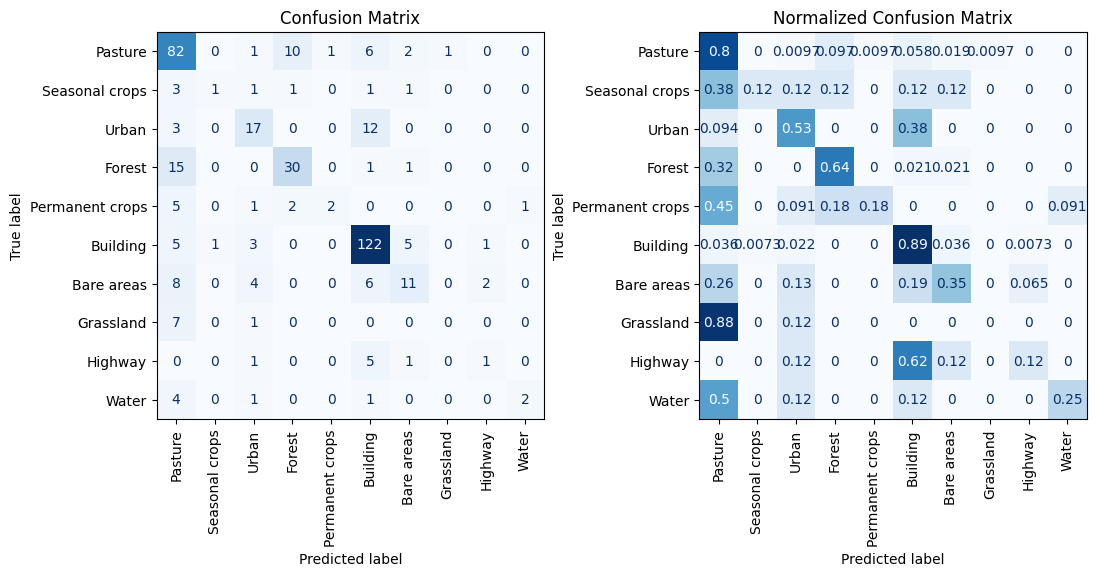

Overall Accuracy: 0.6819338422391857
Classification Report:
                 precision    recall  f1-score   support

     Bare areas       0.52      0.35      0.42        31
       Building       0.79      0.89      0.84       137
         Forest       0.70      0.64      0.67        47
      Grassland       0.00      0.00      0.00         8
        Highway       0.25      0.12      0.17         8
        Pasture       0.62      0.80      0.70       103
Permanent crops       0.67      0.18      0.29        11
 Seasonal crops       0.50      0.12      0.20         8
          Urban       0.57      0.53      0.55        32
          Water       0.67      0.25      0.36         8

       accuracy                           0.68       393
      macro avg       0.53      0.39      0.42       393
   weighted avg       0.66      0.68      0.66       393

--------------------------------------------------
Fold 5 Results:


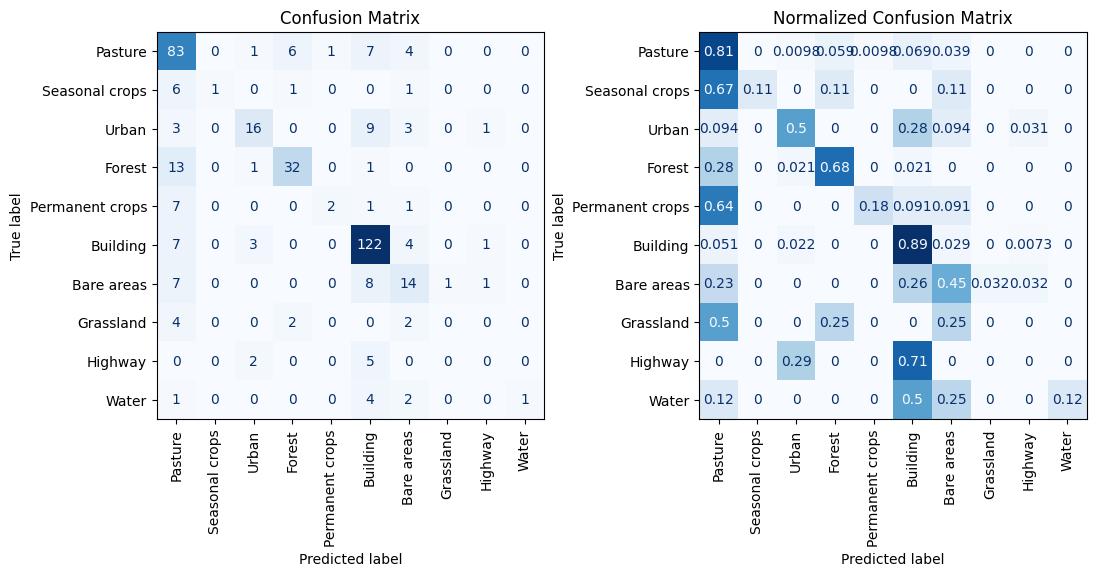

Overall Accuracy: 0.6913265306122449
Classification Report:
                 precision    recall  f1-score   support

     Bare areas       0.45      0.45      0.45        31
       Building       0.78      0.89      0.83       137
         Forest       0.78      0.68      0.73        47
      Grassland       0.00      0.00      0.00         8
        Highway       0.00      0.00      0.00         7
        Pasture       0.63      0.81      0.71       102
Permanent crops       0.67      0.18      0.29        11
 Seasonal crops       1.00      0.11      0.20         9
          Urban       0.70      0.50      0.58        32
          Water       1.00      0.12      0.22         8

       accuracy                           0.69       392
      macro avg       0.60      0.38      0.40       392
   weighted avg       0.68      0.69      0.66       392

--------------------------------------------------


In [27]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold


# Train Random Forest Classifier using Stratified K-Fold Cross-Validation
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for fold, (train_index, val_index) in enumerate(skf.split(X_train_full, y_train_full)):
    X_tr, X_val = X_train_full.iloc[train_index], X_train_full.iloc[val_index]
    y_tr, y_val = y_train_full.iloc[train_index], y_train_full.iloc[val_index]
    
    rf_classifier.fit(X_tr, y_tr)
    
    print(f"Fold {fold + 1} Results:")
    overall_acc, class_acc = compute_accuracy(rf_classifier, X_val, y_val, gdf)
    print(f"Overall Accuracy: {overall_acc}")
    print(f"Classification Report:\n{class_acc}")
    print("-" * 50)

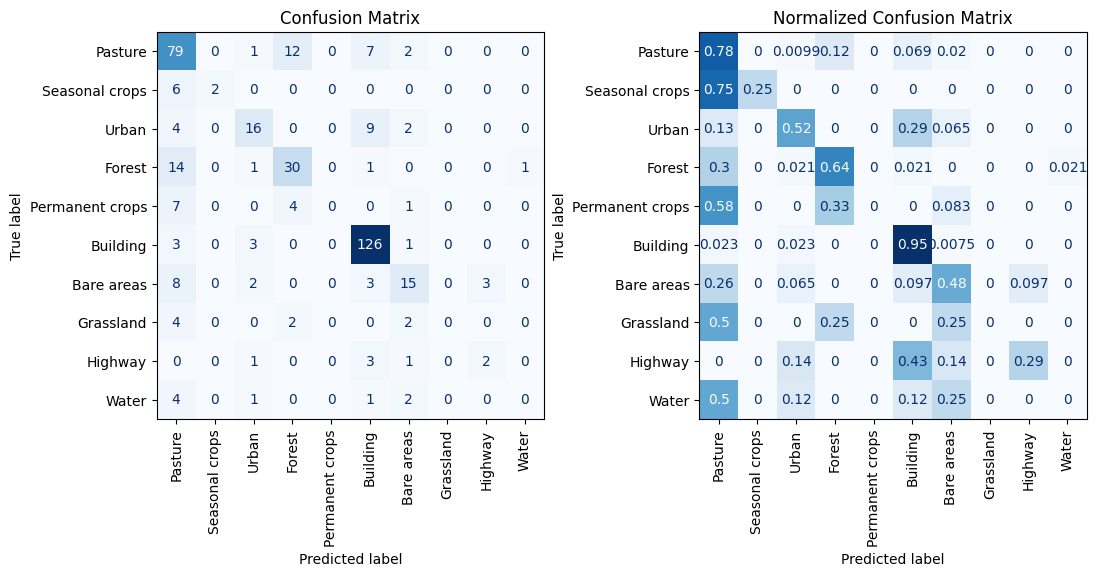

Overall Accuracy : 0.6994818652849741
                 precision    recall  f1-score   support

     Bare areas       0.58      0.48      0.53        31
       Building       0.84      0.95      0.89       133
         Forest       0.62      0.64      0.63        47
      Grassland       1.00      0.00      0.00         8
        Highway       0.40      0.29      0.33         7
        Pasture       0.61      0.78      0.69       101
Permanent crops       1.00      0.00      0.00        12
 Seasonal crops       1.00      0.25      0.40         8
          Urban       0.64      0.52      0.57        31
          Water       0.00      0.00      0.00         8

       accuracy                           0.70       386
      macro avg       0.67      0.39      0.40       386
   weighted avg       0.70      0.70      0.67       386



In [35]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

overall,classification = compute_accuracy(rf, test_gdf[features], test_gdf[target], gdf)
print("Overall Accuracy :",overall) 
print(classification) 

Fitting 10 folds for each of 16 candidates, totalling 160 fits
[CV] END ......................max_depth=10, n_estimators=50; total time=   0.3s
[CV] END ......................max_depth=10, n_estimators=50; total time=   0.4s
[CV] END ......................max_depth=10, n_estimators=50; total time=   0.5s
[CV] END .....................max_depth=10, n_estimators=100; total time=   0.8s
[CV] END .....................max_depth=10, n_estimators=100; total time=   0.7s
[CV] END ......................max_depth=10, n_estimators=50; total time=   0.4s
[CV] END ......................max_depth=10, n_estimators=50; total time=   0.4s
[CV] END ......................max_depth=10, n_estimators=50; total time=   0.4s
[CV] END ......................max_depth=10, n_estimators=50; total time=   0.3s
[CV] END ......................max_depth=10, n_estimators=50; total time=   0.4s
[CV] END ......................max_depth=10, n_estimators=50; total time=   0.4s
[CV] END .....................max_depth=10, n_

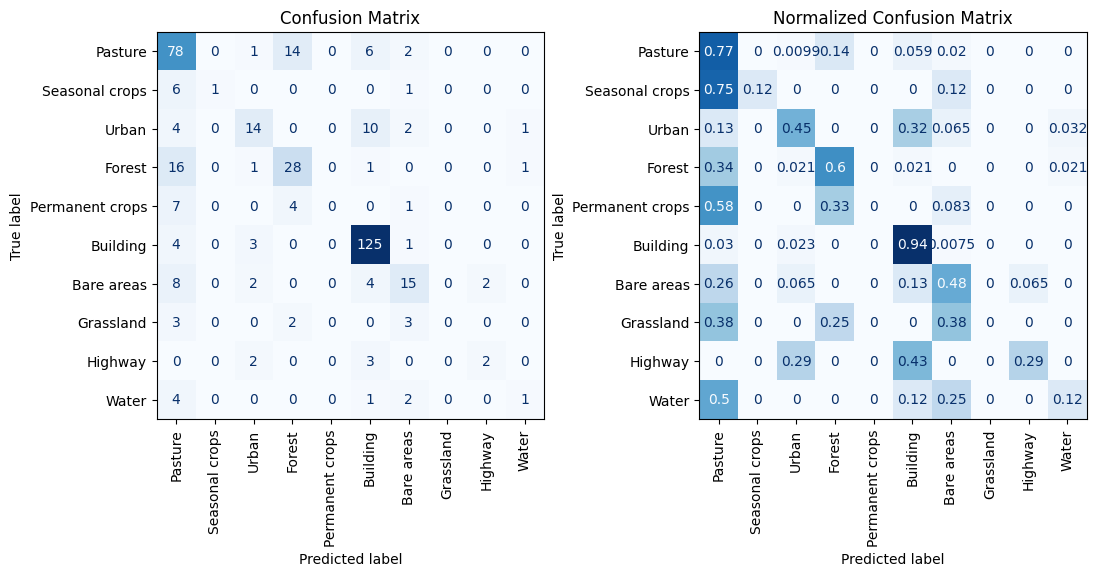

Overall Accuracy after Hyperparameter Tuning: 0.6839378238341969
                 precision    recall  f1-score   support

     Bare areas       0.56      0.48      0.52        31
       Building       0.83      0.94      0.88       133
         Forest       0.58      0.60      0.59        47
      Grassland       1.00      0.00      0.00         8
        Highway       0.50      0.29      0.36         7
        Pasture       0.60      0.77      0.68       101
Permanent crops       1.00      0.00      0.00        12
 Seasonal crops       1.00      0.12      0.22         8
          Urban       0.61      0.45      0.52        31
          Water       0.33      0.12      0.18         8

       accuracy                           0.68       386
      macro avg       0.70      0.38      0.40       386
   weighted avg       0.70      0.68      0.65       386



In [26]:
# Grid search for hyperparameter tuning
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

param_grid = {
    'n_estimators': [50, 100, 200, 300],
    'max_depth': [10, 20, 30, 40],
}

grid_search = GridSearchCV(estimator=RandomForestClassifier(random_state=42), param_grid=param_grid, cv=10, n_jobs=-1, verbose=2)
grid_search.fit(X_train, y_train)

best_rf_classifier = grid_search.best_estimator_
print("Best Hyperparameters:", grid_search.best_params_)

# Get accuracy of best model
overall,classification = compute_accuracy(best_rf_classifier, X_test, y_test, gdf)
print("Overall Accuracy after Hyperparameter Tuning:", overall)
print(classification)

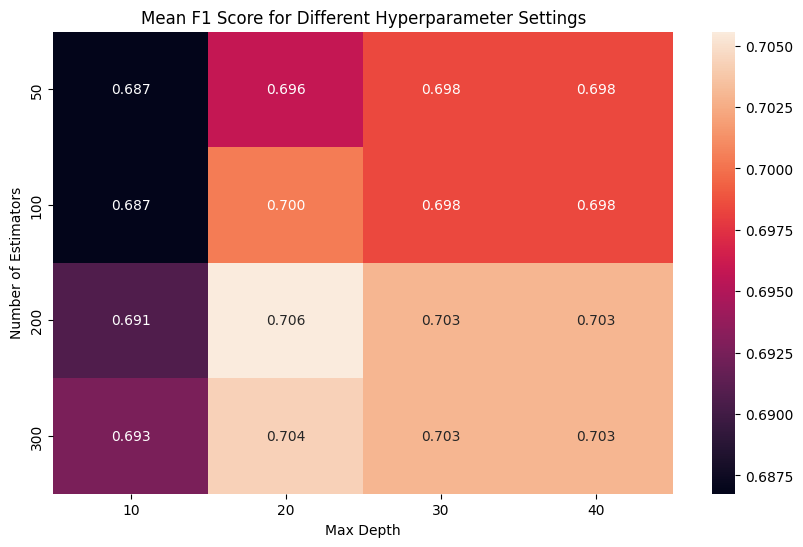

In [27]:
# Plot f1 score results over different hyperparameter settings
import pandas as pd
results = pd.DataFrame(grid_search.cv_results_)
pivot_table = results.pivot(index='param_n_estimators', columns='param_max_depth', values='mean_test_score')
import seaborn as sns
plt.figure(figsize=(10, 6))
sns.heatmap(pivot_table, annot=True, fmt=".3f")
plt.title("Mean F1 Score for Different Hyperparameter Settings")
plt.xlabel("Max Depth")
plt.ylabel("Number of Estimators")
plt.show()

In [66]:
print(rf.feature_importances_)

[0.06877956 0.06330281 0.04833977 0.046174   0.05881323 0.05775545
 0.06045662 0.05846614 0.0964636  0.07361275 0.08907687 0.08600709
 0.19275209]


In [67]:
mdi_importances = pd.Series(
    rf.feature_importances_, index=features
).sort_values(ascending=True)

In [68]:
mdi_importances

r_var       0.046174
r_std       0.048340
g_median    0.057755
g_var       0.058466
g_mean      0.058813
g_std       0.060457
r_median    0.063303
r_mean      0.068780
b_median    0.073613
b_std       0.086007
b_var       0.089077
b_mean      0.096464
area        0.192752
dtype: float64

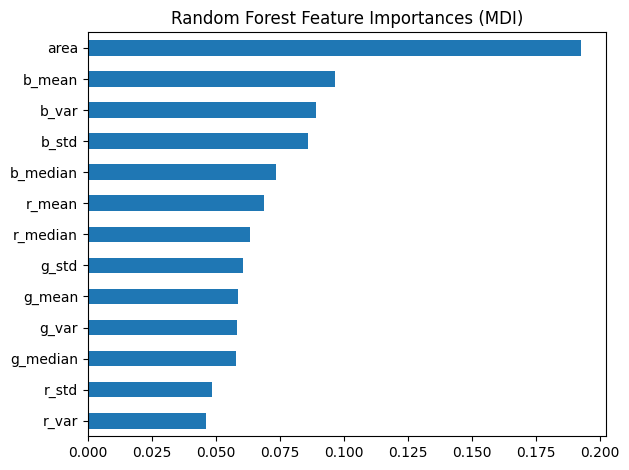

In [69]:
ax = mdi_importances.plot.barh()
ax.set_title("Random Forest Feature Importances (MDI)")
ax.figure.tight_layout()

In [ ]:
from sklearn.ensemble import BaggingClassifier

bc= BaggingClassifier(n_estimators=100,random_state=32) 

bc.fit(X_train_full, y_train_full)

,estimator,None
,n_estimators,100
,max_samples,1.0
,max_features,1.0
,bootstrap,True
,bootstrap_features,False
,oob_score,False
,warm_start,False
,n_jobs,None
,random_state,32
,verbose,0


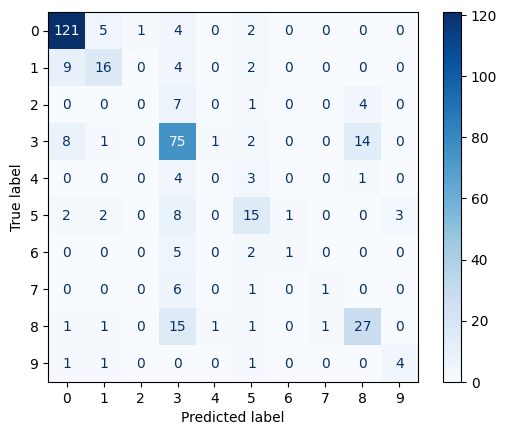

Overall Accuracy : 0.6735751295336787
              precision    recall  f1-score   support

           0       0.85      0.91      0.88       133
          11       0.62      0.52      0.56        31
          12       0.57      0.57      0.57         7
          21       0.50      0.12      0.20         8
          22       0.00      0.00      0.00        12
          23       0.59      0.74      0.66       101
          31       0.59      0.57      0.58        47
          32       0.00      0.00      0.00         8
          33       0.50      0.48      0.49        31
          51       0.50      0.12      0.20         8

    accuracy                           0.67       386
   macro avg       0.47      0.40      0.41       386
weighted avg       0.64      0.67      0.65       386



In [72]:
overall,classification = compute_accuracy(bc)
print("Overall Accuracy :",overall) 
print(classification) 